In [22]:
import pandas as pd

In [23]:
# read the data (green cover, population, UHI)
# path
import pandas as pd

green = pd.read_csv("London_borough_lack_green_cover.csv")
pop = pd.read_csv("borough_density_LQ_2021.csv")
uhi = pd.read_csv("Borough_UHI_Proportion_2022.csv")



In [24]:
# 2. Keep useful columns
green = green[["LAD22CD", "LAD22NM", "lack_green_pct"]]
pop = pop[["LAD22CD", "borough_density"]]
uhi = uhi[["LAD22CD", "UHI_proportion"]]

# 3. Merge tables
df = green.merge(pop, on="LAD22CD", how="inner")
df = df.merge(uhi, on="LAD22CD", how="inner")

#print(df.head())

In [25]:
# 4. Min-max standardisation to 1-5
def minmax_1_5(series):
    return 1 + 4 * (series - series.min()) / (series.max() - series.min())

df["lack_green_score"] = minmax_1_5(df["lack_green_pct"])
df["density_score"] = minmax_1_5(df["borough_density"])
df["uhi_score"] = minmax_1_5(df["UHI_proportion"])

# 5. Calculate Heat Risk Index
df["HRI"] = (
    df["lack_green_score"] +
    df["density_score"] +
    df["uhi_score"]
)
print(df.head())

     LAD22CD               LAD22NM  lack_green_pct  borough_density  \
0  E09000002  Barking and Dagenham       60.534976      6065.630698   
1  E09000003                Barnet       37.432409      4488.866148   
2  E09000004                Bexley       47.111812      4070.427681   
3  E09000005                 Brent       63.965268      7859.510964   
4  E09000006               Bromley       21.094023      2197.687663   

   UHI_proportion  lack_green_score  density_score  uhi_score        HRI  
0        0.768342          3.117901       2.145379   5.000000  10.263281  
1        0.154507          1.877339       1.678466   1.698759   5.254564  
2        0.443091          2.397104       1.554558   3.250781   7.202443  
3        0.588567          3.302101       2.676585   4.033156  10.011842  
4        0.053766          1.000000       1.000000   1.156969   3.156969  


In [26]:
# 6. Sort by HRI
df = df.sort_values("HRI", ascending=False)
df.head(34)

,LAD22CD,LAD22NM,lack_green_pct,borough_density,UHI_proportion,lack_green_score,density_score,uhi_score,HRI
29,E09000030,Tower Hamlets,73.897670,15705.678273,0.425597,3.835452,5.000000,3.156697,11.992149
12,E09000013,Hammersmith and Fulham,73.326595,11161.297281,0.604462,3.804786,3.654313,4.118644,11.577743
11,E09000012,Hackney,63.564860,13593.699185,0.465534,3.280600,4.374599,3.371480,11.026678
24,E09000025,Newham,70.678055,9689.900761,0.602240,3.662565,3.218602,4.106693,10.987860
18,E09000019,Islington,69.467937,14575.536867,0.343603,3.597584,4.665341,2.715726,10.978651
0,E09000002,Barking and Dagenham,60.534976,6065.630698,0.768342,3.117901,2.145379,5.000000,10.263281
21,E09000022,Lambeth,63.575094,11839.524316,0.398758,3.281150,3.855151,3.012353,10.148653
3,E09000005,Brent,63.965268,7859.510964,0.588567,3.302101,2.676585,4.033156,10.011842
31,E09000032,Wandsworth,57.321374,9560.320199,0.507369,2.945337,3.180230,3.596470,9.722037
19,E09000020,Kensington and Chelsea,72.716421,11816.881848,0.220568,3.772021,3.848446,2.054037,9.674503


In [18]:
df.to_csv("London_HRI_result.csv", index=False)

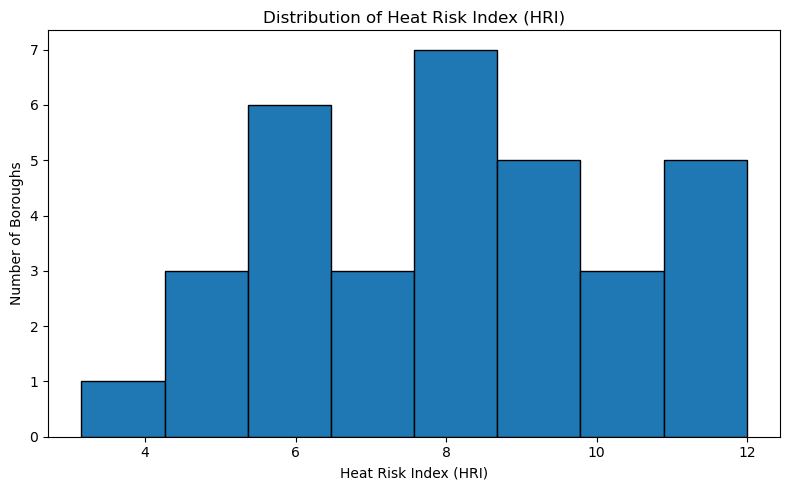

In [27]:
import matplotlib.pyplot as plt

# Make sure HRI is numeric
df["HRI"] = pd.to_numeric(df["HRI"], errors="coerce")

plt.figure(figsize=(8, 5))
plt.hist(df["HRI"].dropna(), bins=8, edgecolor="black")

plt.title("Distribution of Heat Risk Index (HRI)")
plt.xlabel("Heat Risk Index (HRI)")
plt.ylabel("Number of Boroughs")

plt.tight_layout()
plt.show()